<a href="https://colab.research.google.com/github/Dalton115/MAT-422/blob/main/HW1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW1 1.2.1 - 1.2.4

* Used Gemini as a study aid and coding partner to clarify linear algebra definitions, debug python code, and format LaTex formulas.
__________________________________________________________________

1. Singular Value Decomposition (1.4.1)
2. Low-Rank Matrix Approximations (1.4.2)
3. Principal Component Analysis (1.4.3)

__________________________________________________________________

# 1. Singular Value Decomposition 1.4.1

Key Concept (Explained and given python example):

* Mathematically, any matrix can be factored into $$A = U \Sigma V^T$$ which is the singular value decomposition. This formula essentially means any matrix can be broken down into the product of 3 simpler matrices.

To do so, you must find the eigenvalues of $A^TA$, arranging the square root of each non zero eigenvalue into a diagonal matrix gives Σ, then you must find and normalize the eigenvectors to find $V$.

Then you can find $U$ with the formula $u_i = \frac{1}{σ_i}Av_i$

There are many python tools to calculate these values automatically, we can test these and check.

    

* Example:


In [14]:
import numpy as np

# Define an arbitrary non square matrix
A = np.array([
    [3.0, 1.0, 1.0],
    [-1.0, 3.0, 1.0]
    ])

# We can try and test the numpy SVD
U, s, Vt = np.linalg.svd(A, full_matrices = True)

# And construct the sigma matrix
sigma = np.zeros(A.shape)
sigma[:min(A.shape), :min(A.shape)] = np.diag(s)

# Verify reconstruction
A_reconstructed = U @ sigma @ Vt

# now we can do our checks and print our matrices
print("--- MATRIX COMPONENTS ---")
print("Original Matrix A:\n", A)
print("\nLeft Singular Vectors U (2x2):\n", U)
print("\nSingular Values s:\n", s)
print("\nDiagonal Sigma Matrix (2x3):\n", sigma)
print("\nRight Singular Vectors V^T (3x3):\n", Vt)

print("\n--- VERIFICATION CHECKS ---")
print("Reconstructed Matrix (U @ sigma @ V^T):\n", A_reconstructed)

# Check 1: Is the reconstructed matrix equal to A?
is_equal = np.allclose(A, A_reconstructed)
print(f"\n1. Does U @ sigma @ V^T equal A? -> {is_equal}")

# Check 2: Are U and V orthogonal? (U^T @ U should equal Identity)
U_ortho = np.allclose(U.T @ U, np.eye(U.shape[0]))
V_ortho = np.allclose(Vt @ Vt.T, np.eye(Vt.shape[0]))
print(f"2. Is U orthogonal (U^T @ U = I)? -> {U_ortho}")
print(f"3. Is V orthogonal (V^T @ V = I)? -> {V_ortho}")

--- MATRIX COMPONENTS ---
Original Matrix A:
 [[ 3.  1.  1.]
 [-1.  3.  1.]]

Left Singular Vectors U (2x2):
 [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]

Singular Values s:
 [3.46410162 3.16227766]

Diagonal Sigma Matrix (2x3):
 [[3.46410162 0.         0.        ]
 [0.         3.16227766 0.        ]]

Right Singular Vectors V^T (3x3):
 [[-4.08248290e-01 -8.16496581e-01 -4.08248290e-01]
 [-8.94427191e-01  4.47213595e-01  5.26260748e-16]
 [-1.82574186e-01 -3.65148372e-01  9.12870929e-01]]

--- VERIFICATION CHECKS ---
Reconstructed Matrix (U @ sigma @ V^T):
 [[ 3.  1.  1.]
 [-1.  3.  1.]]

1. Does U @ sigma @ V^T equal A? -> True
2. Is U orthogonal (U^T @ U = I)? -> True
3. Is V orthogonal (V^T @ V = I)? -> True


So it checks out, let's also do a semi manual version where we do the individual steps and see if it lines up with the numpy version.

In [15]:
# step 1
ATA = A.T @ A
print("A^T @ A:\n", ATA)

# step 2
# np.linalg.eigh is for symmetric matrices (returns sorted ascending)
eigvals, V_raw = np.linalg.eigh(ATA)

# Sort eigenvalues and eigenvectors in descending order
sort_idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[sort_idx]
V = V_raw[:, sort_idx]

# Singular values are sqrt(eigenvalues)
# Clip at 0 to avoid tiny negative numbers due to floating point error
s_manual = np.sqrt(np.maximum(eigvals, 0))
print("Eigenvalues of A^T @ A:", eigvals)
print("Singular Values (σ = √λ):", s_manual)
print("Matrix V (Right singular vectors):\n", V)

# step 3
# We only take non-zero singular values (here top 2)
k = min(A.shape)
U_manual = np.zeros((A.shape[0], k))

for i in range(k):
    if s_manual[i] > 1e-10:
        U_manual[:, i] = (A @ V[:, i]) / s_manual[i]

print("Matrix U (Left singular vectors):\n", U_manual)

# step 4
Sigma_manual = np.zeros(A.shape)
Sigma_manual[:k, :k] = np.diag(s_manual[:k])

# V^T is the transpose of V
Vt_manual = V.T

A_reconstructed_manual = U_manual @ Sigma_manual @ Vt_manual
print("Reconstructed A (Manual):\n", A_reconstructed_manual)

print("\n--- STEP 5: Compare with np.linalg.svd ---")
# use our values from the np.linalg.svd above...

# Note: Eigenvectors can differ by a sign (direction), so we compare absolute values or reconstruction
manual_matches_np = np.allclose(np.abs(s_manual[:k]), np.abs(s))
reconstruction_matches = np.allclose(A, A_reconstructed_manual)

print(f"Do singular values match NumPy? -> {manual_matches_np}")
print(f"Does manual SVD successfully reconstruct A? -> {reconstruction_matches}")

A^T @ A:
 [[10.  0.  2.]
 [ 0. 10.  4.]
 [ 2.  4.  2.]]
Eigenvalues of A^T @ A: [ 1.20000000e+01  1.00000000e+01 -2.25970772e-15]
Singular Values (σ = √λ): [3.46410162 3.16227766 0.        ]
Matrix V (Right singular vectors):
 [[ 4.08248290e-01  8.94427191e-01  1.82574186e-01]
 [ 8.16496581e-01 -4.47213595e-01  3.65148372e-01]
 [ 4.08248290e-01  2.77555756e-16 -9.12870929e-01]]
Matrix U (Left singular vectors):
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
Reconstructed A (Manual):
 [[ 3.  1.  1.]
 [-1.  3.  1.]]

--- STEP 5: Compare with np.linalg.svd ---
Do singular values match NumPy? -> True
Does manual SVD successfully reconstruct A? -> True


# Low-Rank Matrix Approximations 1.4.2

Key Concept (Explained and given python example):

* Real word data like images may be broken down into matrices (each pixel is an entry that represents color or brightness). They are often large and noisy, and contain dominant patterns (like in images, shading and light sources, textures, or blobs of color).
* Low-rank matrix approximation keeps these dominant structures, while shedding away finer details.
* We use SVD to get these values, where k in the formula $$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T = U_k \Sigma_k V_k^T$$ represents the rank. The lower the value the more broad the patterns it finds are. For example in images, higher ranks may catch finer shapes and colors.
* We can also test the Eckart-Young Theorem, which states SVD gives you the best possible low-rank approximation of a matrix.

Example:
* This example creates a random image (matrix) with added noise, to see how well the different rank approximations approximate the patterns.


--- LOW-RANK RECONSTRUCTION ERRORS ---
Rank k =  1 | Absolute Error: 118.880 | Relative Error: 76.67%
Rank k =  3 | Absolute Error: 43.871 | Relative Error: 28.29%
Rank k =  5 | Absolute Error: 42.032 | Relative Error: 27.11%
Rank k = 20 | Absolute Error: 30.012 | Relative Error: 19.35%


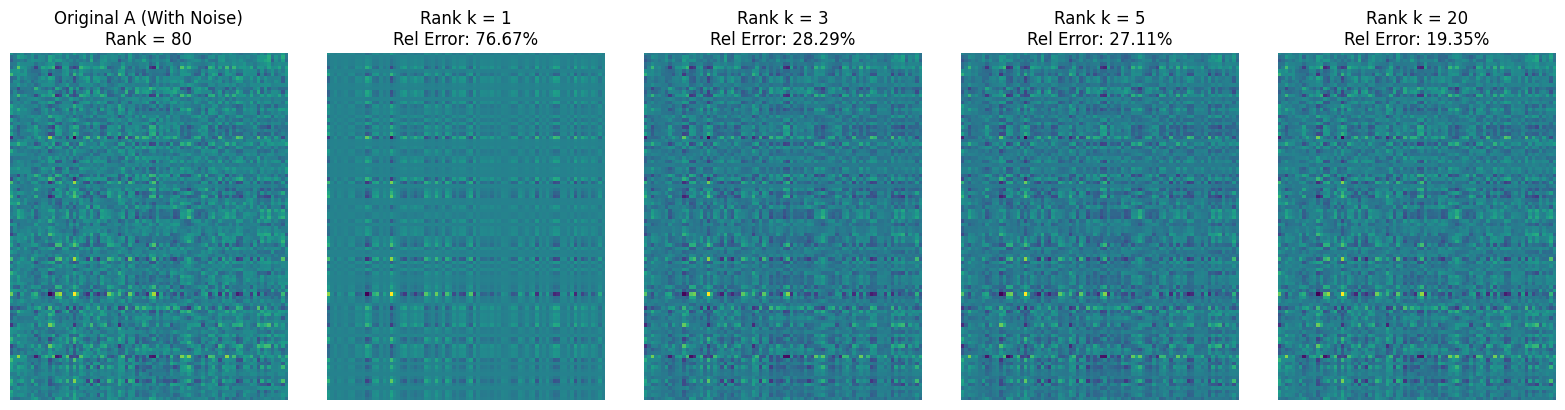


--- THEOREM VERIFICATION (Eckart-Young-Mirsky) ---
Actual ||A - A_3||_F:      43.871133
Theoretical √(Σ σ_i²):  43.871133
Eckart-Young Theorem Holds: True


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a synthetic low-rank structure with added noise
np.random.seed(42)
m, n = 100, 80

# Generate ground-truth rank-3 matrix
U_true = np.random.randn(m, 3)
V_true = np.random.randn(3, n)
A_clean = U_true @ V_true

# Add Gaussian noise
A = A_clean + 0.5 * np.random.randn(m, n)

# 2. Compute full SVD
U, s, Vt = np.linalg.svd(A, full_matrices=False)

# 3. Reconstruct A for different rank thresholds k
ranks = [1, 3, 5, 20]
fig, axes = plt.subplots(1, len(ranks) + 1, figsize=(16, 4))

# Plot Original Matrix A
axes[0].imshow(A, cmap='viridis')
axes[0].set_title(f"Original A (With Noise)\nRank = {np.linalg.matrix_rank(A)}")
axes[0].axis('off')

total_norm = np.linalg.norm(A, 'fro')

print("--- LOW-RANK RECONSTRUCTION ERRORS ---")
for idx, k in enumerate(ranks):
    # Truncate matrices to rank k
    U_k = U[:, :k]
    s_k = s[:k]
    Vt_k = Vt[:k, :]

    # Outer product sum: A_k = U_k @ diag(s_k) @ V_k^T
    A_k = U_k @ np.diag(s_k) @ Vt_k

    # Calculate Frobenius norm of reconstruction error: ||A - A_k||_F
    error_norm = np.linalg.norm(A - A_k, 'fro')
    relative_error = error_norm / total_norm

    print(f"Rank k = {k:2d} | Absolute Error: {error_norm:.3f} | Relative Error: {relative_error:.2%}")

    # Visualize reconstructed matrix
    axes[idx+1].imshow(A_k, cmap='viridis')
    axes[idx+1].set_title(f"Rank k = {k}\nRel Error: {relative_error:.2%}")
    axes[idx+1].axis('off')

plt.tight_layout()
plt.show()

# 4. Math Verification: Check if theoretical residual error matches singular values
# Theoretical Frobenius error: ||A - A_k||_F = sqrt( sum_{i=k+1}^r σ_i^2 )
k_test = 3
actual_error = np.linalg.norm(A - (U[:, :k_test] @ np.diag(s[:k_test]) @ Vt[:k_test, :]), 'fro')
theoretical_error = np.sqrt(np.sum(s[k_test:]**2))

print("\n--- THEOREM VERIFICATION (Eckart-Young-Mirsky) ---")
print(f"Actual ||A - A_{k_test}||_F:      {actual_error:.6f}")
print(f"Theoretical √(Σ σ_i²):  {theoretical_error:.6f}")
print(f"Eckart-Young Theorem Holds: {np.isclose(actual_error, theoretical_error)}")

From this we can see both visually and by the relative error to the original image that the lower ranks do a good job at capturing the broad patterns in the matrix. Additionally, the higher rank the matrices go, the more accurate the approximations become, and the finer details they approximate.



# Principal Component Analysis 1.4.3

* Principal Component Analysis is used to simplify datasets by reducing dimensionality while keeping as much variance in the data as possible.
* To find principal components, we'll need to find the axis with the highest variance, that's your first principal component. The axis perpendicular to PC1 with the highest variance, is the second principal component.
* SVD is the primary algorithm used to calculate PCA.
* To do so, we center the data, by subtracting the mean of each column to center it by the origin. Then perform SVD on the centered data. The eigenvectors or columns of V are the principal directions.
* Multiplying the centered data by V yields the projected data along the principal axes.

Example:

--- VERIFICATION 1: EXPLAINED VARIANCE RATIO ---
Manual SVD Ratios:     [0.91121342 0.08878658]
Scikit-Learn Ratios:   [0.91121342 0.08878658]
Variance Match? -> True

--- VERIFICATION 2: PROJECTED DATA COORDINATES ---
Do Projected Coordinates Match? -> True


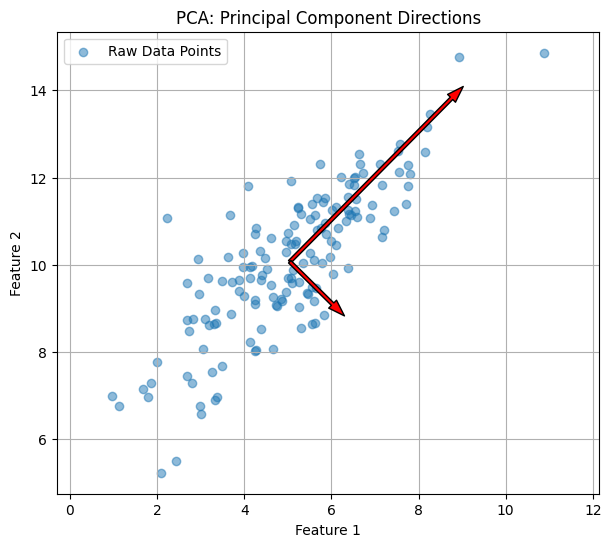

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Generate a correlated 2D Gaussian dataset
np.random.seed(42)
mean = [5, 10]
cov = [[3, 2.5], [2.5, 3]]  # Positive correlation
X = np.random.multivariate_normal(mean, cov, 150)

# 2. Manual PCA using SVD
# Step A: Center the data (crucial step!)
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

# Step B: Compute SVD on centered matrix
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)
V = Vt.T

# Step C: Compute low-dimensional projection
X_projected_svd = X_centered @ V

# Step D: Compute variance explained ratio from singular values
variances_svd = (s ** 2) / (len(X) - 1)
explained_variance_ratio_svd = variances_svd / np.sum(variances_svd)

# 3. Standard Scikit-Learn PCA
pca = PCA(n_components=2)
X_projected_sklearn = pca.fit_transform(X)

print("--- VERIFICATION 1: EXPLAINED VARIANCE RATIO ---")
print("Manual SVD Ratios:    ", explained_variance_ratio_svd)
print("Scikit-Learn Ratios:  ", pca.explained_variance_ratio_)
print("Variance Match? ->", np.allclose(explained_variance_ratio_svd, pca.explained_variance_ratio_))

print("\n--- VERIFICATION 2: PROJECTED DATA COORDINATES ---")
# Vectors can point in opposite directions (sign flip), so we compare absolute values
projections_match = np.allclose(np.abs(X_projected_svd), np.abs(X_projected_sklearn))
print("Do Projected Coordinates Match? ->", projections_match)

# 4. Visualization: Data + Principal Component Directions
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label="Raw Data Points")

# Draw Principal Component Vectors centered at the mean
for length, vector in zip(s / np.sqrt(len(X)), V.T):
    v = vector * length * 2.5
    plt.annotate('', xy=X_mean + v, xytext=X_mean,
                 arrowprops=dict(facecolor='red', shrink=0, width=2.5, headwidth=8))

plt.title("PCA: Principal Component Directions")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

Again, we can see from the image and the projected coordinates matching, that the PCAs correctly capture the variance of the data; pointing directly along the main directional spread. We also see that the our manual implementation matches with sci-kit learn's results.

# Checklist


*   Read, checked, and personalized each example. Also extended at least one example. They run without errors.
*   Covered key concepts from the textbook and illustrated them in python.
*   Explanations written in my own words accompany each example.
*   Saved directly from collab to github.
*   Carefully formatted, code is explained in comments, and it follows the given order from the textbook and in the canvas assignments.
